In [1]:
!pip install -q datasets transformers sacrebleu bert-score nltk evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00


In [2]:
import os, re, random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import nltk

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)

os.makedirs("figures", exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
from datasets import load_dataset

print("Multi30k yükleniyor...")
dataset = load_dataset("bentrevett/multi30k")

train_data = dataset["train"]
val_data   = dataset["validation"]
test_data  = dataset["test"]

print(f"Train : {len(train_data):,} cümle çifti")
print(f"Val   : {len(val_data):,} cümle çifti")
print(f"Test  : {len(test_data):,} cümle çifti")

# Örnek göster
print("\nÖrnek cümle çifti:")
sample = train_data[0]
print(f"  EN: {sample['en']}")
print(f"  DE: {sample['de']}")

# Uzunluk istatistikleri
en_lens = [len(x["en"].split()) for x in train_data]
de_lens = [len(x["de"].split()) for x in train_data]
print(f"\nOrtalama EN uzunluğu: {np.mean(en_lens):.1f} kelime")
print(f"Ortalama DE uzunluğu: {np.mean(de_lens):.1f} kelime")


Multi30k yükleniyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train : 29,000 cümle çifti
Val   : 1,014 cümle çifti
Test  : 1,000 cümle çifti

Örnek cümle çifti:
  EN: Two young, White males are outside near many bushes.
  DE: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.

Ortalama EN uzunluğu: 11.9 kelime
Ortalama DE uzunluğu: 11.1 kelime


In [4]:
from collections import Counter

def tokenize(text):
    """Basit lowercase + noktalama tokenizer."""
    text = text.lower().strip()
    text = re.sub(r"([.!?])", r" \1", text)
    text = re.sub(r"[^a-zA-ZäöüÄÖÜß.!?,\s]", " ", text)
    return text.split()

# Özel tokenlar
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
SPECIAL   = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]
PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3

MIN_FREQ  = 2
MAX_LEN   = 50

def build_vocab(sentences, min_freq=MIN_FREQ):
    counter = Counter()
    for sent in sentences:
        counter.update(tokenize(sent))
    vocab = {tok: i for i, tok in enumerate(SPECIAL)}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

print("Vocabulary oluşturuluyor...")
src_vocab = build_vocab([x["en"] for x in train_data])
trg_vocab = build_vocab([x["de"] for x in train_data])
idx2trg   = {i: w for w, i in trg_vocab.items()}

print(f"EN vocab boyutu: {len(src_vocab):,}")
print(f"DE vocab boyutu: {len(trg_vocab):,}")


def encode(sentence, vocab, max_len=MAX_LEN):
    tokens = tokenize(sentence)[:max_len]
    ids    = [SOS_IDX] + [vocab.get(t, UNK_IDX) for t in tokens] + [EOS_IDX]
    return ids

def collate_fn(batch, src_vocab, trg_vocab):
    """Batch'i padding ile hazırla."""
    src_batch = [encode(x["en"], src_vocab) for x in batch]
    trg_batch = [encode(x["de"], trg_vocab) for x in batch]

    src_max = max(len(s) for s in src_batch)
    trg_max = max(len(s) for s in trg_batch)

    src_padded = [s + [PAD_IDX]*(src_max - len(s)) for s in src_batch]
    trg_padded = [s + [PAD_IDX]*(trg_max - len(s)) for s in trg_batch]

    return (torch.tensor(src_padded, dtype=torch.long).T,   # (src_len, B)
            torch.tensor(trg_padded, dtype=torch.long).T)   # (trg_len, B)

from torch.utils.data import DataLoader
from functools import partial

collate = partial(collate_fn, src_vocab=src_vocab, trg_vocab=trg_vocab)

BATCH_SIZE = 128
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate)

Vocabulary oluşturuluyor...
EN vocab boyutu: 6,290
DE vocab boyutu: 8,431



████████████████████████████████████████████████████████████
  MODEL 1: Seq2Seq + Bahdanau Attention
████████████████████████████████████████████████████████████
Seq2Seq parametreleri: 25,318,639

Seq2Seq eğitimi başlıyor...
Epoch  1/10 | Train Loss: 4.9131 (PPL: 136.06) | Val Loss: 4.7820 (PPL: 119.35)
Epoch  2/10 | Train Loss: 3.8194 (PPL: 45.58) | Val Loss: 3.6833 (PPL: 39.78)
Epoch  3/10 | Train Loss: 2.9609 (PPL: 19.32) | Val Loss: 3.2385 (PPL: 25.50)
Epoch  4/10 | Train Loss: 2.4139 (PPL: 11.18) | Val Loss: 3.1433 (PPL: 23.18)
Epoch  5/10 | Train Loss: 2.0428 (PPL: 7.71) | Val Loss: 3.0914 (PPL: 22.01)
Epoch  6/10 | Train Loss: 1.7641 (PPL: 5.84) | Val Loss: 3.0957 (PPL: 22.10)
Epoch  7/10 | Train Loss: 1.5591 (PPL: 4.75) | Val Loss: 3.0654 (PPL: 21.44)
Epoch  8/10 | Train Loss: 1.3931 (PPL: 4.03) | Val Loss: 3.1796 (PPL: 24.04)
Epoch  9/10 | Train Loss: 1.2790 (PPL: 3.59) | Val Loss: 3.2328 (PPL: 25.35)
Epoch 10/10 | Train Loss: 1.1591 (PPL: 3.19) | Val Loss: 3.2640 (PPL: 26.16

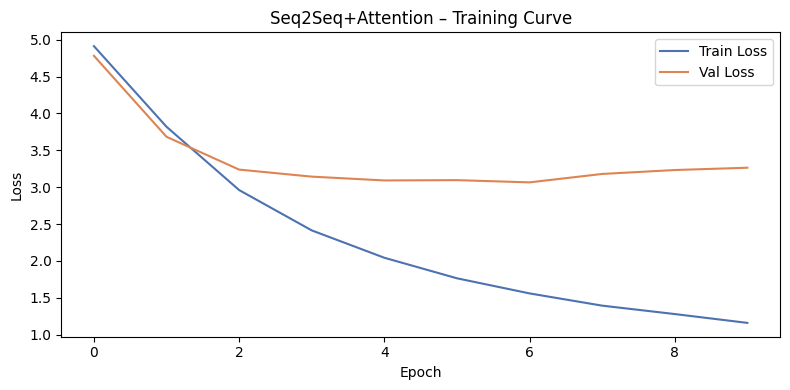

In [5]:
print("\n" + "█"*60)
print("  MODEL 1: Seq2Seq + Bahdanau Attention")
print("█"*60)

# ── Hyperparameters ───────────────────────────────────────────────────────────
EMB_DIM    = 256
HID_DIM    = 512
DROPOUT    = 0.5
EPOCHS_S2S = 10
LR_S2S     = 1e-3
CLIP       = 1.0


class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hid_dim, bidirectional=True, batch_first=False)
        self.fc  = nn.Linear(hid_dim * 2, hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (src_len, B)
        embedded = self.dropout(self.embedding(src))        # (src_len, B, emb)
        outputs, hidden = self.rnn(embedded)                # outputs: (src_len, B, 2*hid)
        # Bidirectional hidden'ı birleştir
        hidden = torch.tanh(self.fc(
            torch.cat([hidden[-2], hidden[-1]], dim=1)))    # (B, hid)
        return outputs, hidden


class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 3, hid_dim)
        self.v    = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (B, hid), encoder_outputs: (src_len, B, 2*hid)
        src_len = encoder_outputs.shape[0]
        hidden  = hidden.unsqueeze(1).repeat(1, src_len, 1)     # (B, src_len, hid)
        enc_out = encoder_outputs.permute(1, 0, 2)              # (B, src_len, 2*hid)
        energy  = torch.tanh(self.attn(torch.cat([hidden, enc_out], dim=2)))
        attention = self.v(energy).squeeze(2)                   # (B, src_len)
        return F.softmax(attention, dim=1)


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(hid_dim)
        self.rnn = nn.GRU(emb_dim + hid_dim * 2, hid_dim, batch_first=False)
        self.fc_out = nn.Linear(hid_dim * 3 + emb_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, trg_token, hidden, encoder_outputs):
        # trg_token: (B,)
        trg_token = trg_token.unsqueeze(0)                      # (1, B)
        embedded  = self.dropout(self.embedding(trg_token))     # (1, B, emb)

        attn_weights = self.attention(hidden, encoder_outputs)  # (B, src_len)
        attn_weights = attn_weights.unsqueeze(1)                # (B, 1, src_len)
        enc_out      = encoder_outputs.permute(1, 0, 2)         # (B, src_len, 2*hid)
        context      = torch.bmm(attn_weights, enc_out)         # (B, 1, 2*hid)
        context      = context.permute(1, 0, 2)                 # (1, B, 2*hid)

        rnn_input = torch.cat([embedded, context], dim=2)       # (1, B, emb+2*hid)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        hidden = hidden.squeeze(0)                              # (B, hid)

        prediction = self.fc_out(torch.cat([
            output.squeeze(0), context.squeeze(0), embedded.squeeze(0)
        ], dim=1))                                              # (B, vocab)
        return prediction, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        trg_len, batch_size = trg.shape
        trg_vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(DEVICE)

        enc_outputs, hidden = self.encoder(src)
        dec_input = trg[0]   # <sos>

        for t in range(1, trg_len):
            output, hidden = self.decoder(dec_input, hidden, enc_outputs)
            outputs[t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            dec_input = trg[t] if teacher_force else output.argmax(1)

        return outputs


# Model oluştur
encoder = Encoder(len(src_vocab), EMB_DIM, HID_DIM, DROPOUT)
decoder = Decoder(len(trg_vocab), EMB_DIM, HID_DIM, DROPOUT)
s2s_model = Seq2Seq(encoder, decoder).to(DEVICE)

def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)
s2s_model.apply(init_weights)

optimizer_s2s = torch.optim.Adam(s2s_model.parameters(), lr=LR_S2S)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print(f"Seq2Seq parametreleri: {sum(p.numel() for p in s2s_model.parameters()):,}")


def train_epoch_s2s(model, loader, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0
    for src, trg in loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()
        output = model(src, trg)                     # (trg_len, B, vocab)
        output = output[1:].reshape(-1, output.shape[-1])
        trg    = trg[1:].reshape(-1)
        loss = criterion(output, trg)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)


def eval_epoch_s2s(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(DEVICE), trg.to(DEVICE)
            output = model(src, trg, teacher_forcing_ratio=0)
            output = output[1:].reshape(-1, output.shape[-1])
            trg    = trg[1:].reshape(-1)
            epoch_loss += criterion(output, trg).item()
    return epoch_loss / len(loader)


print("\nSeq2Seq eğitimi başlıyor...")
history_s2s = {"train": [], "val": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS_S2S + 1):
    tr_loss = train_epoch_s2s(s2s_model, train_loader, optimizer_s2s, criterion, CLIP)
    vl_loss = eval_epoch_s2s(s2s_model, val_loader, criterion)
    history_s2s["train"].append(tr_loss)
    history_s2s["val"].append(vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(s2s_model.state_dict(), "best_s2s.pt")

    print(f"Epoch {epoch:2d}/{EPOCHS_S2S} | "
          f"Train Loss: {tr_loss:.4f} (PPL: {math.exp(tr_loss):.2f}) | "
          f"Val Loss: {vl_loss:.4f} (PPL: {math.exp(vl_loss):.2f})")

# Eğitim eğrisi
plt.figure(figsize=(8, 4))
plt.plot(history_s2s["train"], label="Train Loss", color="#4C72B0")
plt.plot(history_s2s["val"],   label="Val Loss",   color="#DD8452")
plt.title("Seq2Seq+Attention – Training Curve")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.tight_layout()
plt.savefig("figures/q4_s2s_training.png", dpi=150)
plt.show()


# ── Çeviri Fonksiyonu ────────────────────────────────────────────────────────
def translate_s2s(model, sentence, src_vocab, trg_vocab, idx2trg, max_len=50):
    model.eval()
    tokens = encode(sentence, src_vocab)
    src    = torch.tensor(tokens, dtype=torch.long).unsqueeze(1).to(DEVICE)
    with torch.no_grad():
        enc_out, hidden = model.encoder(src)
    dec_input = torch.tensor([SOS_IDX]).to(DEVICE)
    translation = []
    for _ in range(max_len):
        with torch.no_grad():
            output, hidden = model.decoder(dec_input, hidden, enc_out)
        pred = output.argmax(1).item()
        if pred == EOS_IDX:
            break
        translation.append(idx2trg.get(pred, UNK_TOKEN))
        dec_input = torch.tensor([pred]).to(DEVICE)
    return " ".join(translation)



In [6]:
from transformers import MarianMTModel, MarianTokenizer

print("\n" + "█"*60)
print("  MODEL 2: Helsinki-NLP Transformer (EN→DE)")
print("█"*60)

HELSINKI_MODEL = "Helsinki-NLP/opus-mt-en-de"
print(f"Model yükleniyor: {HELSINKI_MODEL}")

mt_tokenizer = MarianTokenizer.from_pretrained(HELSINKI_MODEL)
mt_model     = MarianMTModel.from_pretrained(HELSINKI_MODEL).to(DEVICE)
mt_model.eval()
print(f"Transformer parametreleri: {sum(p.numel() for p in mt_model.parameters()):,}")


def translate_transformer(sentences, batch_size=32):
    """Helsinki-NLP modeli ile toplu çeviri."""
    translations = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        encoded = mt_tokenizer(batch, return_tensors="pt",
                               padding=True, truncation=True,
                               max_length=128).to(DEVICE)
        with torch.no_grad():
            generated = mt_model.generate(**encoded,
                                           num_beams=4,
                                           max_length=128)
        decoded = mt_tokenizer.batch_decode(generated, skip_special_tokens=True)
        translations.extend(decoded)
    return translations


████████████████████████████████████████████████████████████
  MODEL 2: Helsinki-NLP Transformer (EN→DE)
████████████████████████████████████████████████████████████
Model yükleniyor: Helsinki-NLP/opus-mt-en-de


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Transformer parametreleri: 133,905,920


In [7]:
import sacrebleu
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize
from bert_score import score as bert_score_fn

# Test setini hazırla
test_src = [x["en"] for x in test_data]
test_ref = [x["de"] for x in test_data]

# ── Seq2Seq tahminleri ────────────────────────────────────────────────────────
print("Seq2Seq test çevirileri yapılıyor...")
s2s_model.load_state_dict(torch.load("best_s2s.pt"))
s2s_preds = [translate_s2s(s2s_model, sent, src_vocab, trg_vocab, idx2trg)
             for sent in test_src]
print("Seq2Seq tamamlandı.")

# ── Transformer tahminleri ────────────────────────────────────────────────────
print("Transformer test çevirileri yapılıyor...")
transformer_preds = translate_transformer(test_src)
print("Transformer tamamlandı.")


def compute_mt_metrics(predictions, references, model_name="Model"):
    """BLEU, METEOR, ChrF, BERTScore hesapla."""
    print(f"\nMetrikler hesaplanıyor: {model_name}...")

    # BLEU (sacrebleu)
    bleu = sacrebleu.corpus_bleu(predictions, [references]).score

    # METEOR
    meteor_scores = []
    for pred, ref in zip(predictions, references):
        score = meteor_score([word_tokenize(ref.lower())],
                              word_tokenize(pred.lower()))
        meteor_scores.append(score)
    meteor = np.mean(meteor_scores) * 100

    # ChrF
    chrf = sacrebleu.corpus_chrf(predictions, [references]).score

    # BERTScore
    P, R, F1 = bert_score_fn(predictions, references,
                               lang="de", device=str(DEVICE), verbose=False)
    bertscore = F1.mean().item() * 100

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"  BLEU     : {bleu:.2f}")
    print(f"  METEOR   : {meteor:.2f}")
    print(f"  ChrF     : {chrf:.2f}")
    print(f"  BERTScore: {bertscore:.2f}")
    print(f"{'='*55}")
    return {"bleu": bleu, "meteor": meteor, "chrf": chrf, "bertscore": bertscore}


metrics_s2s = compute_mt_metrics(s2s_preds, test_ref, "Seq2Seq + Attention")
metrics_tr  = compute_mt_metrics(transformer_preds, test_ref, "Helsinki Transformer")


Seq2Seq test çevirileri yapılıyor...
Seq2Seq tamamlandı.
Transformer test çevirileri yapılıyor...


Transformer tamamlandı.

Metrikler hesaplanıyor: Seq2Seq + Attention...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Seq2Seq + Attention
  BLEU     : 4.94
  METEOR   : 56.97
  ChrF     : 43.04
  BERTScore: 76.45

Metrikler hesaplanıyor: Helsinki Transformer...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Helsinki Transformer
  BLEU     : 36.24
  METEOR   : 66.68
  ChrF     : 64.25
  BERTScore: 89.66



████████████████████████████████████████████████████████████
  KALİTATİF ÖRNEK
████████████████████████████████████████████████████████████

────────────────────────────────────────────────────────────
ÖRNEK 1
  [EN - Kaynak]     : A man in an orange hat starring at something.
  [DE - Referans]   : Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
  [Seq2Seq Çıktısı] : ein mann mit einem orangefarbenen hut starrt etwas etwas an .
  [Transformer]     : Ein Mann in einem orangenen Hut, der mit etwas zu tun hat.

────────────────────────────────────────────────────────────
ÖRNEK 2
  [EN - Kaynak]     : A Boston Terrier is running on lush green grass in front of a white fence.
  [DE - Referans]   : Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.
  [Seq2Seq Çıktısı] : ein <unk> hirtenhund rennt auf grünes grünes gras vor einem weißen zaun .
  [Transformer]     : Ein Boston Terrier läuft auf üppig grünem Gras vor einem weißen Zaun.

─────────────────────────

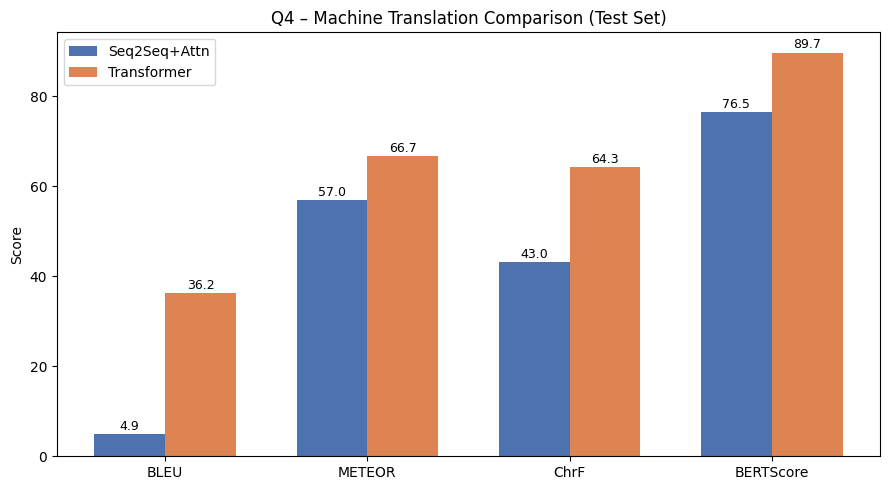


✅ Q4 tamamlandı!


In [8]:
print("\n" + "█"*60)
print("  KALİTATİF ÖRNEK")
print("█"*60)

for i in range(3):
    print(f"\n{'─'*60}")
    print(f"ÖRNEK {i+1}")
    print(f"  [EN - Kaynak]     : {test_src[i]}")
    print(f"  [DE - Referans]   : {test_ref[i]}")
    print(f"  [Seq2Seq Çıktısı] : {s2s_preds[i]}")
    print(f"  [Transformer]     : {transformer_preds[i]}")

# ── Karşılaştırma Tablosu ─────────────────────────────────────────────────────
print("\n" + "═"*60)
print("  GENEL SONUÇLAR (Test Seti)")
print("═"*60)
print(f"  {'Metrik':<12} {'Seq2Seq':>12} {'Transformer':>14}")
print("-"*60)
for key in ["bleu","meteor","chrf","bertscore"]:
    print(f"  {key:<12} {metrics_s2s[key]:>12.2f} {metrics_tr[key]:>14.2f}")
print("═"*60)

# Bar chart
metrics_labels = ["BLEU", "METEOR", "ChrF", "BERTScore"]
s2s_vals = [metrics_s2s[k] for k in ["bleu","meteor","chrf","bertscore"]]
tr_vals  = [metrics_tr[k]  for k in ["bleu","meteor","chrf","bertscore"]]

x = np.arange(len(metrics_labels))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, s2s_vals, w, label="Seq2Seq+Attn", color="#4C72B0")
b2 = ax.bar(x + w/2, tr_vals,  w, label="Transformer",  color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(metrics_labels)
ax.set_ylabel("Score")
ax.set_title("Q4 – Machine Translation Comparison (Test Set)")
ax.legend()
for bar in b1.patches + b2.patches:
    ax.annotate(f"{bar.get_height():.1f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/q4_comparison.png", dpi=150)
plt.show()

print("\n✅ Q4 tamamlandı!")
